# <center>**Baseline Models - Logistic Regression and Random Forest**</center>

We train two classical models on the normalized LOB features to establish a hard benchmark before building deep learning architectures.

**Models:** Logistic Regression · Random Forest  
**Task:** 3-class classification → UP (1) / STATIONARY (0) / DOWN (-1)  
**Metric:** Macro F1-Score (handles class imbalance fairly)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, accuracy_score,
    classification_report, ConfusionMatrixDisplay
)

### Load the Pre-split Data

In [5]:
train_df = pd.read_parquet('train.parquet')
val_df   = pd.read_parquet('val.parquet')
test_df  = pd.read_parquet('test.parquet')

train_df.head(1)

,mid_price,spread,vol_imbalance_1,vol_imbalance_5,weighted_mid,label
timestamp,,,,,,
2026-07-05 02:20:13.300255,0.994987,0.0,0.897599,0.903098,1.002736,0


In [6]:
FEATURE_COLS = ['mid_price', 'spread', 'vol_imbalance_1', 'vol_imbalance_5', 'weighted_mid']
TARGET_COL   = 'label'

X_train, y_train = train_df[FEATURE_COLS].values, train_df[TARGET_COL].values
X_val,   y_val   = val_df[FEATURE_COLS].values,   val_df[TARGET_COL].values
X_test,  y_test  = test_df[FEATURE_COLS].values,  test_df[TARGET_COL].values

print(f'Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}')
print(f'\nLabel distribution (train):')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label_name = {1: 'UP', 0: 'STATIONARY', -1: 'DOWN'}.get(int(u), str(u))
    print(f'  {label_name:>12} ({int(u):>2}): {c:>6} rows  ({100*c/len(y_train):.1f}%)')

Train : (346997, 5)  |  Val : (74356, 5)  |  Test : (74357, 5)

Label distribution (train):
          DOWN (-1):   1491 rows  (0.4%)
    STATIONARY ( 0): 344274 rows  (99.2%)
            UP ( 1):   1232 rows  (0.4%)


### Logistic Regression
A linear classifier. If this performs well, the LOB features have strong linear predictive power.

In [7]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

lr_val_preds = lr.predict(X_val)
lr_f1  = f1_score(y_val, lr_val_preds, average='macro')
lr_acc = accuracy_score(y_val, lr_val_preds)

print('── Logistic Regression (Validation) ──')
print(f'Macro F1 : {lr_f1:.4f}')
print(f'Accuracy : {lr_acc:.4f}')
print()
print(classification_report(y_val, lr_val_preds, target_names=['DOWN', 'STATIONARY', 'UP']))

── Logistic Regression (Validation) ──
Macro F1 : 0.1904
Accuracy : 0.3716

              precision    recall  f1-score   support

        DOWN       0.01      0.59      0.02       321
  STATIONARY       0.99      0.37      0.54     73757
          UP       0.01      0.72      0.02       278

    accuracy                           0.37     74356
   macro avg       0.34      0.56      0.19     74356
weighted avg       0.99      0.37      0.53     74356



### Random Forest
An ensemble of decision trees. Captures non-linear interactions between features.

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

rf_val_preds = rf.predict(X_val)
rf_f1  = f1_score(y_val, rf_val_preds, average='macro')
rf_acc = accuracy_score(y_val, rf_val_preds)

print('── Random Forest (Validation) ──')
print(f'Macro F1 : {rf_f1:.4f}')
print(f'Accuracy : {rf_acc:.4f}')
print()
print(classification_report(y_val, rf_val_preds, target_names=['DOWN', 'STATIONARY', 'UP']))

── Random Forest (Validation) ──
Macro F1 : 0.2718
Accuracy : 0.6410

              precision    recall  f1-score   support

        DOWN       0.01      0.40      0.02       321
  STATIONARY       0.99      0.64      0.78     73757
          UP       0.01      0.39      0.02       278

    accuracy                           0.64     74356
   macro avg       0.34      0.48      0.27     74356
weighted avg       0.99      0.64      0.77     74356



### Confusion Matrices

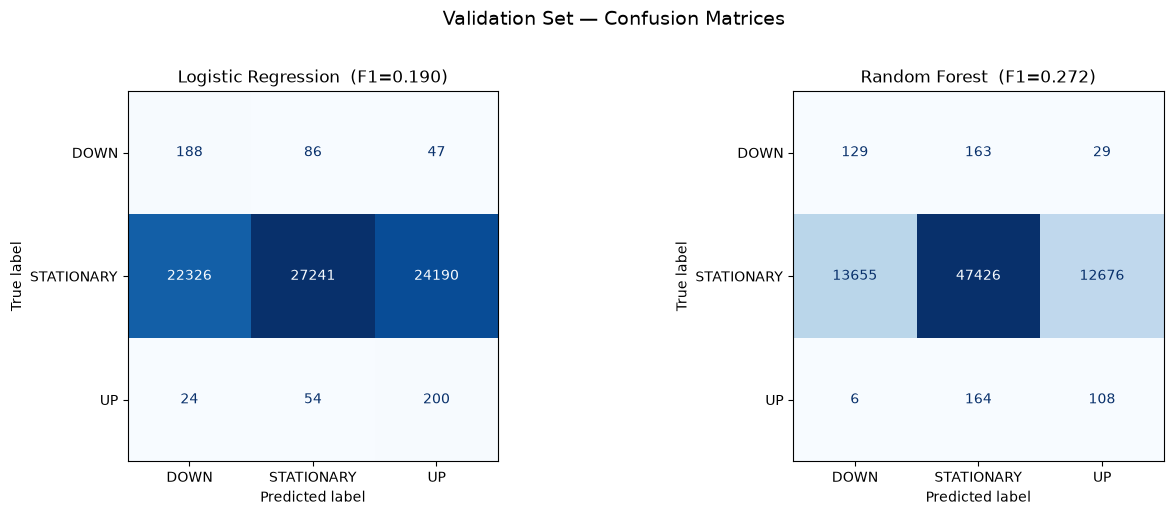

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_names = ['DOWN', 'STATIONARY', 'UP']

for ax, model, preds, name in zip(
    axes,
    [lr, rf],
    [lr_val_preds, rf_val_preds],
    ['Logistic Regression', 'Random Forest']
):
    ConfusionMatrixDisplay.from_predictions(
        y_val, preds,
        display_labels=class_names,
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'{name}  (F1={f1_score(y_val, preds, average="macro"):.3f})')

plt.suptitle('Validation Set — Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Feature Importance (Random Forest)

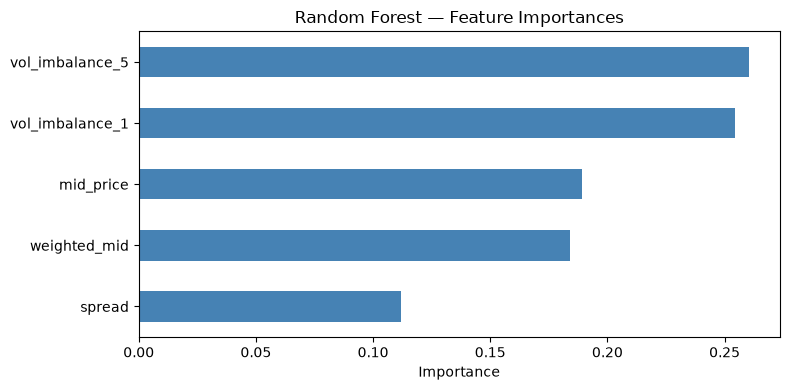

In [10]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Random Forest — Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### Final Evaluation on Test Set
> ⚠️ Only run this once you are done tuning. Looking at test results repeatedly leaks information and inflates your final numbers.

In [11]:
# Choose the best model from validation results above before running this cell
best_model      = rf          # ← change to lr if Logistic Regression wins
best_model_name = 'Random Forest'

test_preds = best_model.predict(X_test)
test_f1    = f1_score(y_test, test_preds, average='macro')
test_acc   = accuracy_score(y_test, test_preds)

print(f'── {best_model_name} (TEST SET — FINAL) ──')
print(f'Macro F1 : {test_f1:.4f}')
print(f'Accuracy : {test_acc:.4f}')
print()
print(classification_report(y_test, test_preds, target_names=['DOWN', 'STATIONARY', 'UP']))
print()
print(f'>>> Baseline to beat in deep learning: Macro F1 = {test_f1:.4f} <<<')

── Random Forest (TEST SET — FINAL) ──
Macro F1 : 0.2817
Accuracy : 0.6651

              precision    recall  f1-score   support

        DOWN       0.01      0.46      0.03       347
  STATIONARY       0.99      0.67      0.80     73709
          UP       0.01      0.45      0.02       301

    accuracy                           0.67     74357
   macro avg       0.34      0.53      0.28     74357
weighted avg       0.99      0.67      0.79     74357


>>> Baseline to beat in deep learning: Macro F1 = 0.2817 <<<
